In [1]:
import numpy as np
import scipy as sp
import matplotlib as mpl
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
#standard normally distributed data = gaussian with zero mean and unit variance
# to center data ={remove the mean value of each feature/ scale by dividing non-constant by their standard deviation}
#used for performing processing on database

from sklearn import preprocessing

In [3]:
X_train=np.array([[1.,-1.,2.],
                  [2.,0.,0.],
                  [0.,1.,-1.]])
scaler=preprocessing.StandardScaler().fit(X_train)
scaler
#standardscale -> standardize features -> mean=0, std= 1 formula : x=x-mean/standard dev -> z score normalization

#!!! scaling done column-wise

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [4]:
scaler.mean_
#mean of each feature 

array([1.        , 0.        , 0.33333333])

In [5]:
scaler.scale_
#standard deviation for each column 

array([0.81649658, 0.81649658, 1.24721913])

In [ ]:
#We use fit for training data , then transform for using the same mean and scale for the test data

In [6]:
X_scaled=scaler.transform(X_train)
X_scaled

array([[ 0.        , -1.22474487,  1.33630621],
       [ 1.22474487,  0.        , -0.26726124],
       [-1.22474487,  1.22474487, -1.06904497]])

In [7]:
print("mean: ",X_scaled.mean(axis=0),", std: ",X_scaled.std(axis=0))
#axis=0 -> column-wise
#axis=1 -> row-wise

mean:  [0. 0. 0.] , std:  [1. 1. 1.]


In [ ]:
#disable centering -> with_mean=False 
#disable scaling -> with_std=False
#parameters for StandardScaler

In [ ]:
#scaling so that the features lie between a given minimum and maximum
#or so tha max abs value of each feature is scaled to unit size
#MinMaxScaler or MaxAbsScaler

In [8]:
X_train = np.array([[ 1., -1.,  2.],
                     [ 2.,  0.,  0.],
                     [ 0.,  1., -1.]])

min_max_scaler = preprocessing.MinMaxScaler()
X_train_minmax = min_max_scaler.fit_transform(X_train)
X_train_minmax

array([[0.5       , 0.        , 1.        ],
       [1.        , 0.5       , 0.33333333],
       [0.        , 1.        , 0.        ]])

In [9]:
X_test=np.array([[-3.,-1.,4.]])
X_test_minmax=min_max_scaler.transform(X_test)
X_test_minmax

array([[-1.5       ,  0.        ,  1.66666667]])

In [11]:
min_max_scaler.scale_


array([0.5       , 0.5       , 0.33333333])

In [12]:
min_max_scaler.min_

array([0.        , 0.5       , 0.33333333])

In [ ]:
#for a specific range , formula for min_max_scaler is 
#x std= (x-x.min)/(x.max-x.min)
#x scaled= x std *(max-min)+min

#we use max abs scaler for already centered data or sparse data, same concept but dividing each feature wit the max value so that it lies in the range [-1,1]

In [13]:
X_train = np.array([[ 1., -1.,  2.],
                     [ 2.,  0.,  0.],
                     [ 0.,  1., -1.]])

max_abs_scaler = preprocessing.MaxAbsScaler()
X_train_maxabs = max_abs_scaler.fit_transform(X_train)
X_train_maxabs

array([[ 0.5, -1. ,  1. ],
       [ 1. ,  0. ,  0. ],
       [ 0. ,  1. , -0.5]])

In [14]:
X_test = np.array([[ -3., -1.,  4.]])
X_test_maxabs = max_abs_scaler.transform(X_test)
X_test_maxabs

array([[-1.5, -1. ,  2. ]])

In [15]:
max_abs_scaler.scale_

array([2., 1., 2.])

In [17]:
#normalization - scale individual samples to have unit norm
#used when using quadratic form -> dot product , when quantifying the similarity of any pair samples

X = [[ 1., -1.,  2.],
  [ 2.,  0.,  0.],
  [ 0.,  1., -1.]]

X_normalized = preprocessing.normalize(X, norm='l2')

X_normalized

array([[ 0.40824829, -0.40824829,  0.81649658],
       [ 1.        ,  0.        ,  0.        ],
       [ 0.        ,  0.70710678, -0.70710678]])

In [18]:
#encoding categorical features -> change non-numerical features into numerical ones

#OrdinalEncoder -> 0-> ncat-1
enc = preprocessing.OrdinalEncoder()
X = [['male', 'from US', 'uses Safari'], ['female', 'from Europe', 'uses Firefox']]
enc.fit(X)


,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute.",'auto'
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'use_encoded_value'}, default='error'When set to 'error' an error will be raised in case an unknowncategorical feature is present during transform. When set to'use_encoded_value', the encoded value of unknown categories will beset to the value given for the parameter `unknown_value`. In:meth:`inverse_transform`, an unknown category will be denoted as None... versionadded:: 0.24",'error'
,"unknown_value unknown_value: int or np.nan, default=NoneWhen the parameter handle_unknown is set to 'use_encoded_value', thisparameter is required and will set the encoded value of unknowncategories. It has to be distinct from the values used to encode any ofthe categories in `fit`. If set to np.nan, the `dtype` parameter mustbe a float dtype... versionadded:: 0.24",None
,"encoded_missing_value encoded_missing_value: int or np.nan, default=np.nanEncoded value of missing categories. If set to `np.nan`, then the `dtype`parameter must be a float dtype... versionadded:: 1.1",nan
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.3 Read more in the :ref:`User Guide `.",None
,"max_categories max_categories: int, default=NoneSpecifies an upper limit to the number of output categories for each inputfeature when considering infrequent categories. If there are infrequentcategories, `max_categories` includes the category representing theinfrequent categories along with the frequent categories. If `None`,there is no limit to the number of output features.`max_categories` do **not** take into account missing or unknowncategories. Setting `unknown_value` or `encoded_missing_value` to aninteger will increase the number of unique integer codes by one each.This can result in up to `max_categories + 2` integer codes... versionadded:: 1.3 Read more in the :ref:`User Guide `.",None


In [19]:
enc.transform([['female','from US','uses Safari']])

array([[0., 1., 1.]])

In [20]:
enc = preprocessing.OrdinalEncoder()
X = [['male'], ['female'], [np.nan], ['female']]
enc.fit_transform(X)

array([[ 1.],
       [ 0.],
       [nan],
       [ 0.]])

In [21]:
enc = preprocessing.OrdinalEncoder(encoded_missing_value=-1)
X = [['male'], ['female'], [np.nan], ['female']]
enc.fit_transform(X)

array([[ 1.],
       [ 0.],
       [-1.],
       [ 0.]])

EXERCISE 1


In [5]:
#Load the dataset WA_Fn-UseC_-Telco-Customer-Churn.csv provided. Perform transformations on it so it is prepared to build a model (scaling the numerical data and the cathegorical features transformed in numerical integer labels.

data=pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
y=data['Churn']
X_data=data.drop(['Churn'],axis=1)

categorical_cols=X_data.select_dtypes(include='object').columns
numeric_cols=X_data.select_dtypes(exclude='object').columns

enc=preprocessing.OrdinalEncoder()
X_data[categorical_cols]=enc.fit_transform(X_data[categorical_cols])

scl=preprocessing.StandardScaler()
X_data[numeric_cols] = scl.fit_transform(X_data[numeric_cols])

print(X_data.head())
#numeric -> scale, non-numeric -> encode

   customerID  gender  SeniorCitizen  Partner  Dependents    tenure  \
0      5375.0     0.0      -0.439916      1.0         0.0 -1.277445   
1      3962.0     1.0      -0.439916      0.0         0.0  0.066327   
2      2564.0     1.0      -0.439916      0.0         0.0 -1.236724   
3      5535.0     1.0      -0.439916      0.0         0.0  0.514251   
4      6511.0     0.0      -0.439916      0.0         0.0 -1.236724   

   PhoneService  MultipleLines  InternetService  OnlineSecurity  OnlineBackup  \
0           0.0            1.0              0.0             0.0           2.0   
1           1.0            0.0              0.0             2.0           0.0   
2           1.0            0.0              0.0             2.0           2.0   
3           0.0            1.0              0.0             2.0           0.0   
4           1.0            0.0              1.0             0.0           0.0   

   DeviceProtection  TechSupport  StreamingTV  StreamingMovies  Contract  \
0         

C:\Users\Alexandra\AppData\Local\Temp\ipykernel_21824\745283095.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols=X_data.select_dtypes(include='object').columns


LINEAR REGRESSION

In [26]:
#Linear regression 

#provides linear relationship (indep var - dep var) => predicts outcome

x_train=np.array([1,2,3])
y_train=np.array([2,3,6])
type(x_train)


(3,)

In [27]:
x_train.shape

(3,)

In [28]:
x_train=x_train.reshape(3,1)
x_train.shape

(3, 1)

(3, 1) (3, 1)


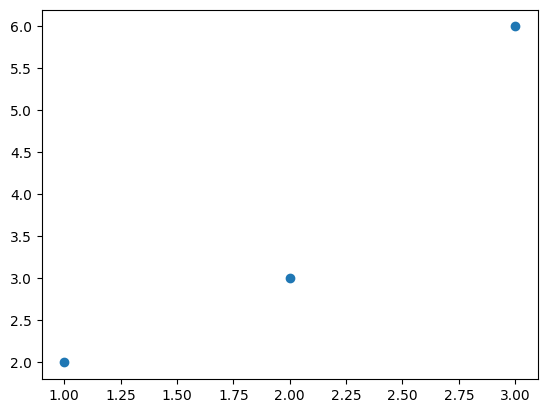

In [33]:
#scatterplot
plt.scatter(x_train,y_train)
# check dimensions 
print(x_train.shape,y_train.shape)

<Axes: title={'center': 'A nice plot'}, xlabel='$x$', ylabel='$y$'>

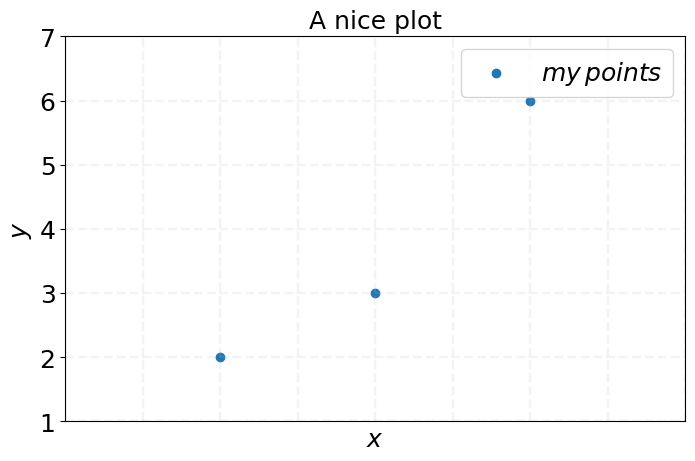

In [30]:
def nice_scatterplot(x,y,title):
    f_size=18
    fig,ax=plt.subplots(1,1,figsize=(8,5))
    ax.set_xlim(np.min(x)-1,np.max(x)+1)
    ax.set_ylim(np.min(y)-1,np.max(y)+1)
    ax.tick_params(labelsize=f_size)
    ax.tick_params(labelbottom=False,bottom=False)
    
    ax.set_xlabel(r'$x$',fontsize=f_size)
    ax.set_ylabel(r'$y$',fontsize=f_size)
    ax.set_title(title,fontsize=f_size)
    
    ax.grid(True,lw=1.75,ls='--',alpha=0.15)
    
    ax.scatter(x, y, label=r'$my\,points$')
    ax.legend(loc='best', fontsize = f_size);
    
    return ax

nice_scatterplot(x_train,y_train,'A nice plot')

In [ ]:
#formula for linear regression
#a=sum(xi-meanx)(yi-meany)/sum(xi-meanx)^2
#b=meany-a* meanx

In [31]:
xx = np.array([[1,2,3],[4,6,8]])
xxx = xx.reshape(-1,2)
#reshape -1 -> calculates the dimension
xxx.shape

(3, 2)

In [34]:
x_train = x_train.reshape(x_train.shape[0], 1)
y_train = y_train.reshape(y_train.shape[0], 1)

print(x_train.shape)

(3, 1)


In [35]:
y_bar = np.mean(y_train)
x_bar = np.mean(x_train)

numerator = np.sum( (x_train - x_bar)*(y_train - y_bar) )
denominator = np.sum((x_train - x_bar)**2)

print(numerator.shape, denominator.shape) 

() ()


In [36]:
#slope a
a = numerator/denominator

#intercept b
b = y_bar - a * x_bar

print("The best-fit line is {0:3.2f} + {1:3.2f} * x".format(b, a))
print(f'The best fit is {b}')

The best-fit line is -0.33 + 2.00 * x
The best fit is -0.3333333333333335


In [7]:
def simple_linear_regression_fit(x_train: np.ndarray, y_train: np.ndarray) -> np.ndarray:
    """
    Inputs:
    x_train: a (num observations by 1) array holding the values of the predictor variable
    y_train: a (num observations by 1) array holding the values of the response variable

    Returns:
    beta_vals:  a (num_features by 1) array holding the intercept and slope coeficients
    """
    
    # Check input array sizes
    if len(x_train.shape) < 2:
        print("Reshaping features array.")
        x_train = x_train.reshape(x_train.shape[0], 1)

    if len(y_train.shape) < 2:
        print("Reshaping observations array.")
        y_train = y_train.reshape(y_train.shape[0], 1)

    # first, compute means
    y_bar = np.mean(y_train)
    x_bar = np.mean(x_train)
     # build the two terms
    numerator = np.sum( (x_train - x_bar)*(y_train - y_bar) )
    denominator = np.sum((x_train - x_bar)**2)
    
    #slope a
    a = numerator/denominator

    #intercept b
    b = y_bar - a*x_bar

    return np.array([b,a])

In [9]:
x_train=np.array([1,2,3])
y_train=np.array([2,2,4])

coeficients=simple_linear_regression_fit(x_train,y_train)

a=coeficients[1]
b=coeficients[0]

print("The best-fit line is {1:8.6f} + {0:8.6f} * x".format(a,b))

Reshaping features array.
Reshaping observations array.
The best-fit line is 0.666667 + 1.000000 * x


Text(0, 0.5, '$y$')

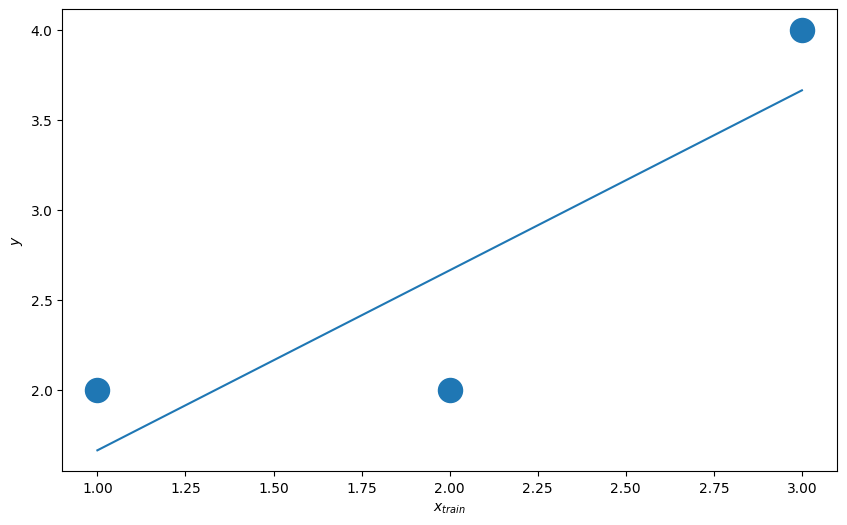

In [10]:
fig_scat, ax_scat = plt.subplots(1,1, figsize=(10,6))

x_train=np.array([1,2,3]).T
best_fit=b+a*x_train

ax_scat.scatter(x_train,y_train,s=300,label='Training data')
ax_scat.plot(x_train,best_fit,label='Best fit')

ax_scat.set_xlabel(r'$x_{train}$')
ax_scat.set_ylabel(r'$y$')

STATSMODELS AND SKLEARN

In [12]:
#statsmodels -> foind slope and intercept
#sklearn -> guess y values 

#use either if not specified

import statsmodels.api as sm

In [14]:
X=sm.add_constant(x_train)
print(X)

toyregr_sm=sm.OLS(y_train,X)

results_sm=toyregr_sm.fit()

beta0_sm=results_sm.params[0]
beta1_sm=results_sm.params[1]

print(f'the regression coef statsmodels are : beta_0 = {beta0_sm:8.6f} and beta_1 = {beta1_sm:8.6f}')



[[1. 1.]
 [1. 2.]
 [1. 3.]]
the regression coef statsmodels are : beta_0 = 0.666667 and beta_1 = 1.000000


In [15]:
import warnings
warnings.filterwarnings('ignore')
print(results_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.750
Model:                            OLS   Adj. R-squared:                  0.500
Method:                 Least Squares   F-statistic:                     3.000
Date:                Sat, 07 Mar 2026   Prob (F-statistic):              0.333
Time:                        22:14:28   Log-Likelihood:                -2.0007
No. Observations:                   3   AIC:                             8.001
Df Residuals:                       1   BIC:                             6.199
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6667      1.247      0.535      0.6

In [16]:
from sklearn import linear_model

In [18]:
toyregr=linear_model.LinearRegression()

results=toyregr.fit(X,y_train)

beta0_skl=toyregr.intercept_
beta1_skl=toyregr.coef_[0]

print("The regression coefficients from the sklearn are : beta_0 = {0:8.6f} and beta_1 = {1:8.6f}".format(beta0_skl, beta1_skl))

The regression coefficients from the sklearn are : beta_0 = 0.666667 and beta_1 = 0.000000


In [ ]:
#estimator implements fit and predict

In [ ]:
#estimator.fit(Xtrain, ytrain)

In [ ]:
#our estimator is the linear regression
#X_train needs to be 2x2 -> each row=sample, each column= feature values
#y_train = response array


In [20]:
df = pd.read_csv('Salary_dataset.csv')

In [21]:
print(df.head())

   Unnamed: 0  YearsExperience   Salary
0           0              1.2  39344.0
1           1              1.4  46206.0
2           2              1.6  37732.0
3           3              2.1  43526.0
4           4              2.3  39892.0


In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

print(df.head())
X = np.array(df['YearsExperience'])
y = np.array(df['Salary'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

   Unnamed: 0  YearsExperience   Salary
0           0              1.2  39344.0
1           1              1.4  46206.0
2           2              1.6  37732.0
3           3              2.1  43526.0
4           4              2.3  39892.0


In [23]:
X_train

array([ 5.4,  8. ,  3. ,  5.2,  3.3,  4.6,  8.3,  6.9,  1.4, 10.6,  3.1,
        2.3,  6. ,  6.1,  3.8,  3.3,  9.1,  2.1,  1.2,  7.2,  5. ,  4.1])

In [24]:
y_train

array([ 83089., 101303.,  56643.,  66030.,  64446.,  61112., 113813.,
        91739.,  46206., 121873.,  60151.,  39892.,  81364.,  93941.,
        57190.,  54446., 105583.,  43526.,  39344.,  98274.,  67939.,
        56958.])

In [25]:
# rember to reshape the X list in order to have a two dimensional array. 
# Since we have only one feature the reshape looks like below: 
X_train = X_train.reshape(-1, 1)
X_test = X_test.reshape(-1, 1)

# we perform the regression
lr = LinearRegression().fit(X_train, y_train)


print(f"Linear Regression-Training set score: {lr.score(X_train, y_train):.2f}")
print(f"Linear Regression-Test set score: {lr.score(X_test, y_test):.2f}")

Linear Regression-Training set score: 0.94
Linear Regression-Test set score: 0.98


In [26]:
a = lr.coef_[0] 
b = lr.intercept_ 
 
print(a, "* x +", b, "= y")

9379.710491946016 * x + 26049.720267542645 = y


In [27]:
lr.predict([[20]])

array([213643.93010646])

In [28]:
a * 20 + b

np.float64(213643.93010646297)

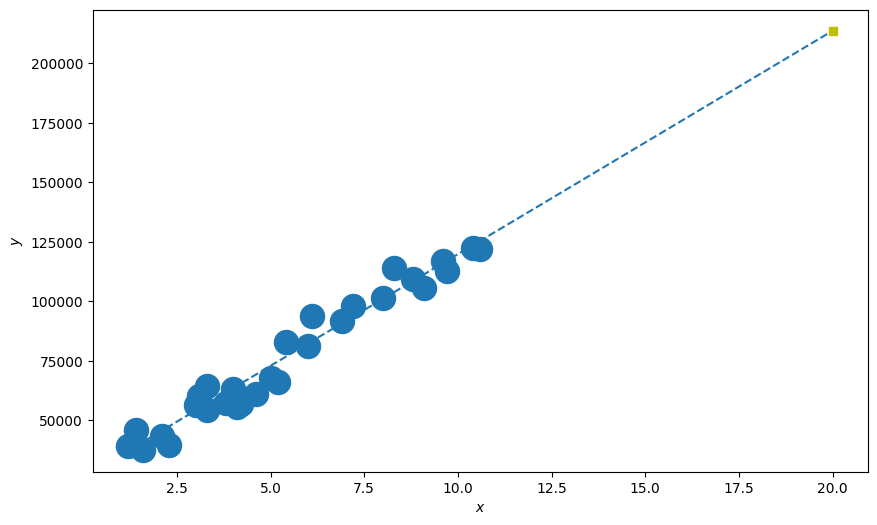

In [29]:
pred = lr.predict([[20]])
fig_scat, ax_scat = plt.subplots(1,1, figsize=(10,6))


x = X.T

best_fit = b + a * (np.append(x, [20]))

ax_scat.scatter(x, y, s=300, label='Training Data')
ax_scat.plot(np.append(x,[20]), best_fit, ls='--', label='Best Fit Line')

ax_scat.plot([20],pred, "ys", label="LinearRegression")
ax_scat.set_xlabel(r'$x$')
ax_scat.set_ylabel(r'$y$');


EXERCISE 2

In [10]:
#Download from https://www.kaggle.com/ the regression dataset: Student Study Hours. Create a model and make 3 predictions. Make some nice graphics to depict the model (training set, test set, predictions).
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
my_db = pd.read_csv('score_updated.csv')
my_db.head()

,Hours,Scores
0,2.5,21
1,5.1,47
2,3.2,27
3,8.5,75
4,3.5,30


In [11]:

my_X = np.array(my_db['Hours'])
my_y = np.array(my_db['Scores'])

my_X_train, my_X_test, my_y_train, my_y_test = train_test_split(my_X, my_y, test_size=0.25, random_state=0)
my_X_train = my_X_train.reshape(-1,1)
my_X_test = my_X_test.reshape(-1,1)
"""reshape as 1 feature"""

my_lr = LinearRegression().fit(my_X_train, my_y_train)
my_a = my_lr.coef_[0]
my_b = my_lr.intercept_
prediction1 = my_lr.predict([[9]])[0]
prediction2 = my_lr.predict([[10]])[0]
prediction3 = my_lr.predict([[12]])[0]

print(f"My predictions: {prediction1:8.4f}, {prediction2:8.4f}, {prediction3:8.4f}")

My predictions:  91.5650, 101.5790, 121.6069


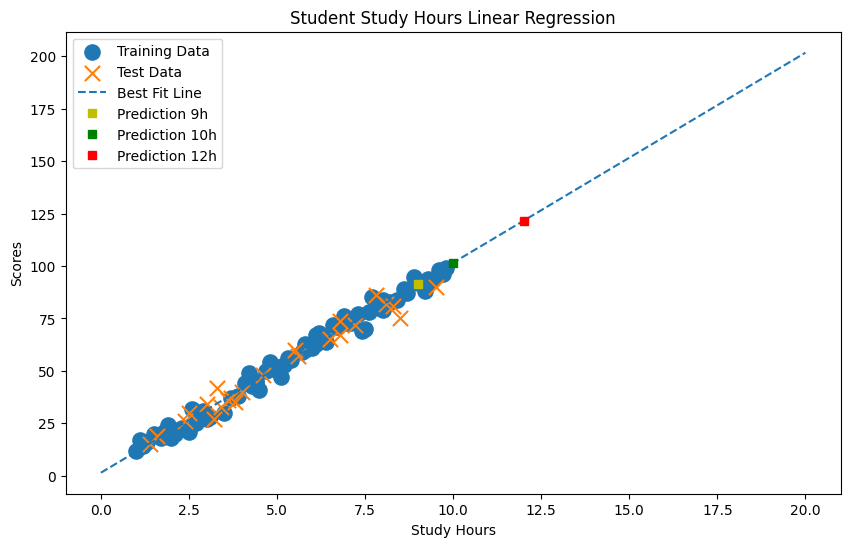

In [14]:

x_line = np.linspace(0,20,100)
y_line = my_b + my_a * x_line

my_fig_scat, my_ax_scat = plt.subplots(1,1, figsize=(10,6))
my_ax_scat.scatter(my_X_train, my_y_train, s=120, label='Training Data')

my_ax_scat.scatter(my_X_test, my_y_test, s=120, label='Test Data', marker='x')

my_ax_scat.plot(x_line, y_line, '--', label='Best Fit Line')

my_ax_scat.plot([9], [prediction1], "ys", label="Prediction 9h")
my_ax_scat.plot([10], [prediction2], "gs", label="Prediction 10h")
my_ax_scat.plot([12], [prediction3], "rs", label="Prediction 12h")

my_ax_scat.set_xlabel("Study Hours")

my_ax_scat.set_ylabel("Scores")

my_ax_scat.set_title("Student Study Hours Linear Regression")

my_ax_scat.legend()

plt.show()

REGULARIZATION

In [ ]:
# restrict a model -> avoid overfitting
# regularization=loss function+ penalty

#l2/l1/elastic net

#l2 : ridge regr cost fct=loss fct+ 1/2 *lambda * sum(omegaj^2)
#lambda-> strength of regularization
#omega are the weights



In [46]:

X_train = X_train.reshape(-1, 1)
X_test = X_test.reshape(-1, 1)

from sklearn.linear_model import Ridge

ridge = Ridge(alpha=0.7).fit(X_train, y_train)

print(f"Ridge Regression-Training set score: {ridge.score(X_train, y_train):.2f}")
print(f"Ridge Regression-Test set score: {ridge.score(X_test, y_test):.2f}")

Ridge Regression-Training set score: 0.99
Ridge Regression-Test set score: 0.97


In [47]:
#l1 reg ->ignore the least importannt
#lasso regrestion cost function = loss function + r* lambda * sum(abs(gamaj))

# rember to reshape the X list in order to have a two dimensional array. 
# Since we have only one feature the reshape looks like below: 
X_train = X_train.reshape(-1, 1)
X_test = X_test.reshape(-1, 1)

from sklearn.linear_model import Lasso

lasso = Lasso(alpha=1.0).fit(X_train, y_train)

print(f"Lasso Regression-Training set score: {lasso.score(X_train, y_train):.2f}")
print(f"Lasso Regression-Test set score: {lasso.score(X_test, y_test):.2f}")

Lasso Regression-Training set score: 0.99
Lasso Regression-Test set score: 0.97


In [ ]:
#elastic net


In [48]:
# loss function + r*lambda*sum(abs(omegaj))+ (1-r)/2 * lambda* sum(omegaj^2)
# rember to reshape the X list in order to have a two dimensional array. 
# Since we have only one feature the reshape looks like below: 
X_train = X_train.reshape(-1, 1)
X_test = X_test.reshape(-1, 1)

from sklearn.linear_model import ElasticNet

elastic_net = ElasticNet(alpha=0.01, l1_ratio=0.01).fit(X_train, y_train)

print(f"Elastic Net-Training set score: {elastic_net.score(X_train, y_train):.2f}")
print(f"Elastic Net-Test set score: {elastic_net.score(X_test, y_test):.2f}")

Elastic Net-Training set score: 0.99
Elastic Net-Test set score: 0.97


EXERCISE 3

In [54]:
#For your build previous model perform all three regularizations presented here.
my_X_train = my_X_train.reshape(-1, 1)
my_X_test = my_X_test.reshape(-1, 1)

from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet

ridge = Ridge(alpha=0.7).fit(my_X_train, my_y_train)
lasso = Lasso(alpha=1.0).fit(my_X_train, my_y_train)
elastic_net = ElasticNet(alpha=0.01, l1_ratio=0.01).fit(my_X_train, my_y_train)
print(f"Ridge Regression-Training set score: {ridge.score(my_X_train, my_y_train):.2f}")
print(f"Ridge Regression-Test set score: {ridge.score(my_X_test, my_y_test):.2f}")
print(f"Lasso Regression-Training set score: {lasso.score(my_X_train, my_y_train):.2f}")
print(f"Lasso Regression-Test set score: {lasso.score(my_X_test, my_y_test):.2f}")
print(f"Elastic Net-Training set score: {elastic_net.score(my_X_train, my_y_train):.2f}")
print(f"Elastic Net-Test set score: {elastic_net.score(my_X_test, my_y_test):.2f}")

Ridge Regression-Training set score: 0.99
Ridge Regression-Test set score: 0.97
Lasso Regression-Training set score: 0.99
Lasso Regression-Test set score: 0.97
Elastic Net-Training set score: 0.99
Elastic Net-Test set score: 0.97
